In [39]:
import warnings
from sklearn.exceptions import ConvergenceWarning
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [40]:
## Data Cleaning and Preprocessing

# Font Setting
matplotlib.rcParams['font.family'] = 'cmr10'

# silences: 'UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True'
matplotlib.rcParams['axes.formatter.use_mathtext'] = True

# Read the dataset using Pandas
Dummy = pd.read_csv("Dummy.csv")

print("-"*30)
# Show basic information about the dataset
rows, cols = Dummy.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

print()

# Clean the data
# Check for missing data
missing_count = Dummy.isnull().sum()
print("Missing values per column:\n", missing_count)

# Check for duplicate data
duplicate_count = Dummy.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Drop rows and columns with missing values
Dummy_cleaned = Dummy.dropna(axis=0).dropna(axis=1)

# Check the number of remaining data
print()
remaining_rows, remaining_cols = Dummy_cleaned.shape
print(f"Number of rows left after dropping missing values: {remaining_rows}")
print(f"Number of columns left after dropping missing values: {remaining_cols}")
print("-" * 30)

------------------------------
Number of rows: 1887
Number of columns: 14

Missing values per column:
 pid      0
rep      0
X_1      0
X_2      0
X_3      0
X_4      0
X_5      0
X_6      0
X_7      0
X_8      0
X_9      0
cnc      0
cls      0
group    0
dtype: int64
Number of duplicate rows: 0

Number of rows left after dropping missing values: 1887
Number of columns left after dropping missing values: 14
------------------------------


In [41]:
## Class balance and label distribution

# Collapse to patient level (the 3 replicates per "pid" share the same labels)

# Check that every patient have exactly one: cnc, cls, group
lbls_per_pid = Dummy.groupby("pid")[["cnc", "cls", "group"]].nunique()
assert (lbls_per_pid == 1).all().all() # this condition must be true

# Keep only one row per patient for the following analyses
patients = Dummy.drop_duplicates(subset="pid").copy()
print(f"Rows in file: {len(Dummy)}   |   Unique patients: {patients['pid'].nunique()}")
print()

# Number of cancer (C)/ non-cancer (NC) counts and percentages
counts = patients["cnc"].value_counts()
percent = patients["cnc"].value_counts(normalize=True).mul(100).round(1)
print("Cancer vs non-cancer:")
print(pd.DataFrame({"count": counts, "percent": percent}))
print()

# Check that cancer subtypes (cls) sit under cancer (cnc)
print("Subtype (cls) vs cancer label (cnc):")
print(pd.crosstab(patients["cls"], patients["cnc"], margins=True))
print()

# Check whether group is confounded with class?
print(pd.crosstab(patients["group"], patients["cnc"], margins=True)) # counts
print((pd.crosstab(patients["group"], patients["cnc"], normalize="index")*100).round(1)) # cancer rate per group
print ()

# Check how subtypes spread across groups
print("Subtype (cls) vs group:")
print(pd.crosstab(patients["cls"], patients["group"], margins=True))
print()

# Full three-way breakdown
print("Full breakdown (number of patients per combination):")
print(patients.groupby(["group", "cnc", "cls"]).size().rename("n").reset_index())

Rows in file: 1887   |   Unique patients: 629

Cancer vs non-cancer:
     count  percent
cnc                
NC     399     63.4
C      230     36.6

Subtype (cls) vs cancer label (cnc):
cnc        C   NC  All
cls                   
cancer1  118    0  118
cancer2  112    0  112
control    0  399  399
All      230  399  629

cnc       C   NC  All
group                
group1   78  131  209
group2   86  123  209
group3   66  145  211
All     230  399  629
cnc        C    NC
group             
group1  37.3  62.7
group2  41.1  58.9
group3  31.3  68.7

Subtype (cls) vs group:
group    group1  group2  group3  All
cls                                 
cancer1      41      43      34  118
cancer2      37      43      32  112
control     131     123     145  399
All         209     209     211  629

Full breakdown (number of patients per combination):
    group cnc      cls    n
0  group1   C  cancer1   41
1  group1   C  cancer2   37
2  group1  NC  control  131
3  group2   C  cancer1   43
4  gro

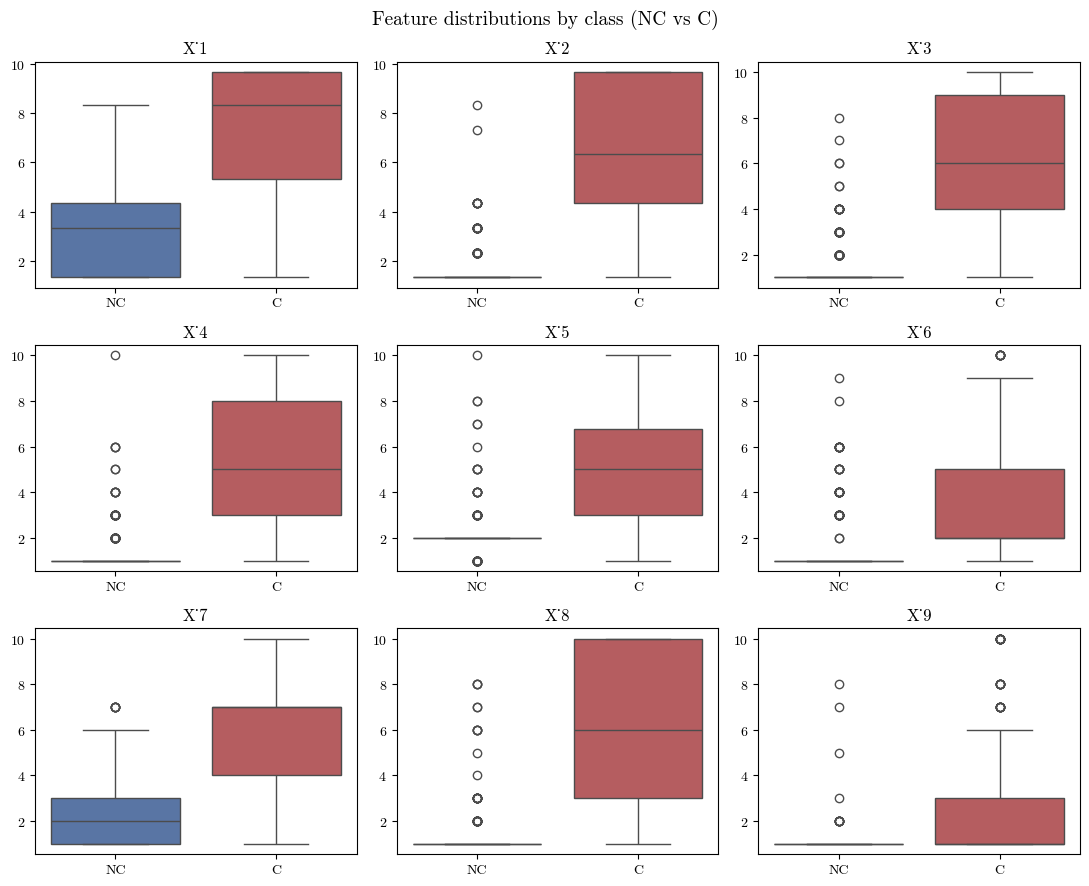

In [42]:
## Determine the features that are most different between cancer (C) and non-cancer (NC) patients

# Average the 3 replicates so each patient contributes one value per feature
features = [f"X_{i}" for i in range(1, 10)]
patients = Dummy.groupby(["pid", "cnc"], as_index=False)[features].mean()

# 3x3 grid: one boxplot per feature, split by cancer (C) vs non-cancer (NC)
fig, axes = plt.subplots(3, 3, figsize=(11, 9))

for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=patients, x="cnc", y=feat, hue="cnc",
                order=["NC", "C"], palette={"NC": "#4c72b0", "C": "#c44e52"},
                legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Feature distributions by class (NC vs C)", fontsize=14)
fig.tight_layout()
plt.show()

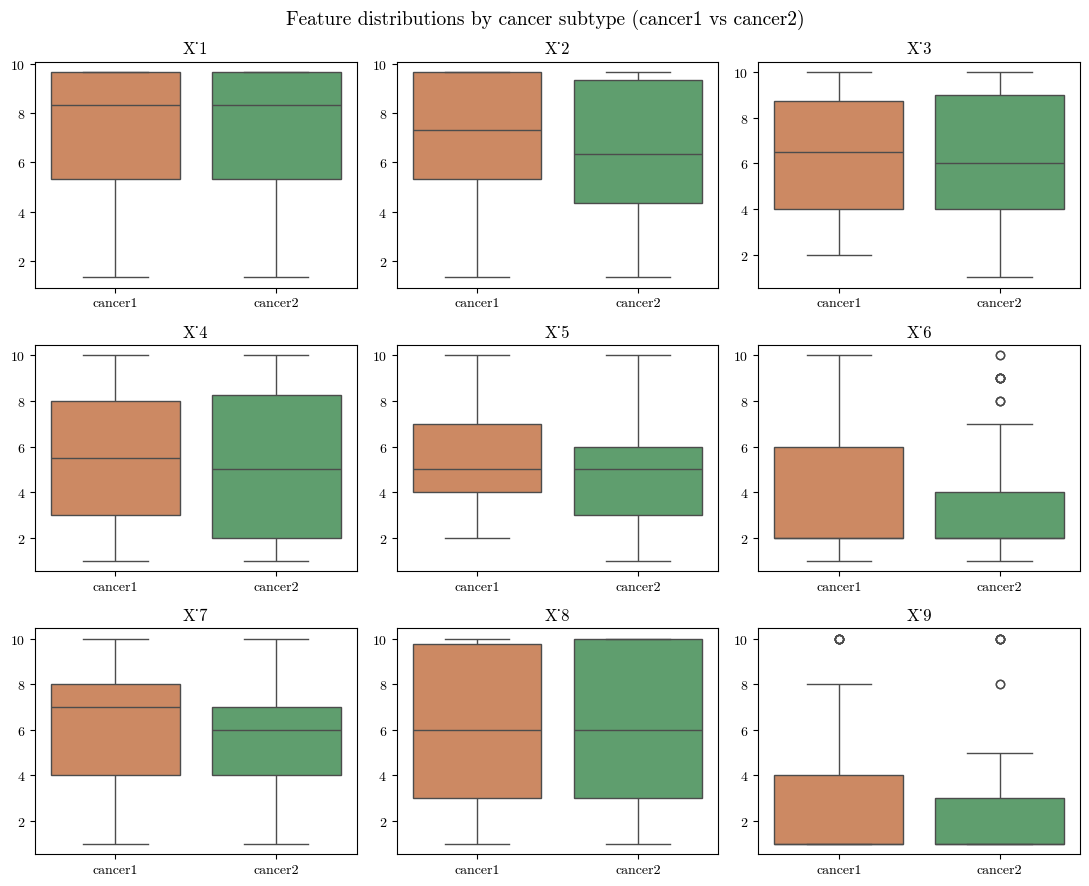

In [43]:
## Determine the features that are most different between cancer1 and cancer2 patients

features = [f"X_{i}" for i in range(1, 10)]

# Average replicates per patient, then keep ONLY the two cancer subtypes
patients = Dummy.groupby(["pid", "cls"], as_index=False)[features].mean()
cancers  = patients[patients["cls"].isin(["cancer1", "cancer2"])]

# 3x3 grid: one boxplot per feature, split by cancer1 vs cancer2
fig, axes = plt.subplots(3, 3, figsize=(11, 9))

for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=cancers, x="cls", y=feat, hue="cls",
                order=["cancer1", "cancer2"],
                palette={"cancer1": "#dd8452", "cancer2": "#55a868"},
                legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Feature distributions by cancer subtype (cancer1 vs cancer2)", fontsize=14)
fig.tight_layout()
plt.show()

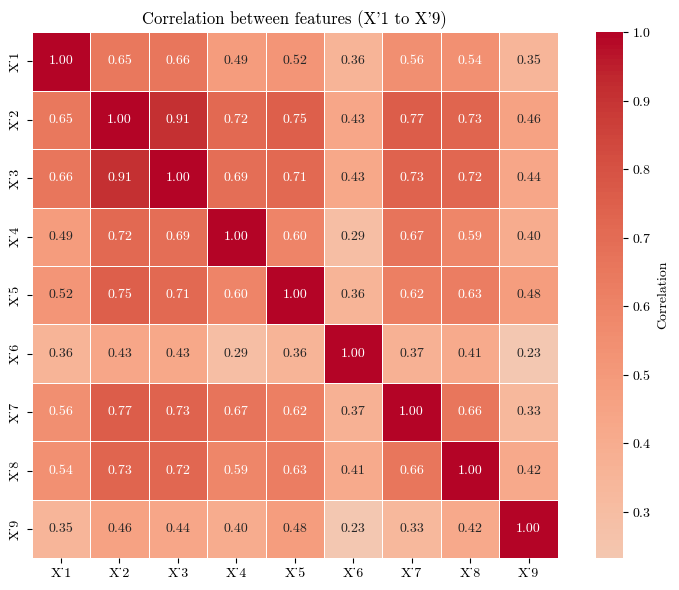

In [44]:
## Heatmap of feature correlations

features = [f"X_{i}" for i in range(1, 10)]

# One row per patient (average the 3 replicates), then correlate the 9 features
patients = Dummy.groupby("pid", as_index=False)[features].mean()
corr = patients[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation between features (X'1 to X'9)")
plt.tight_layout()
plt.show()

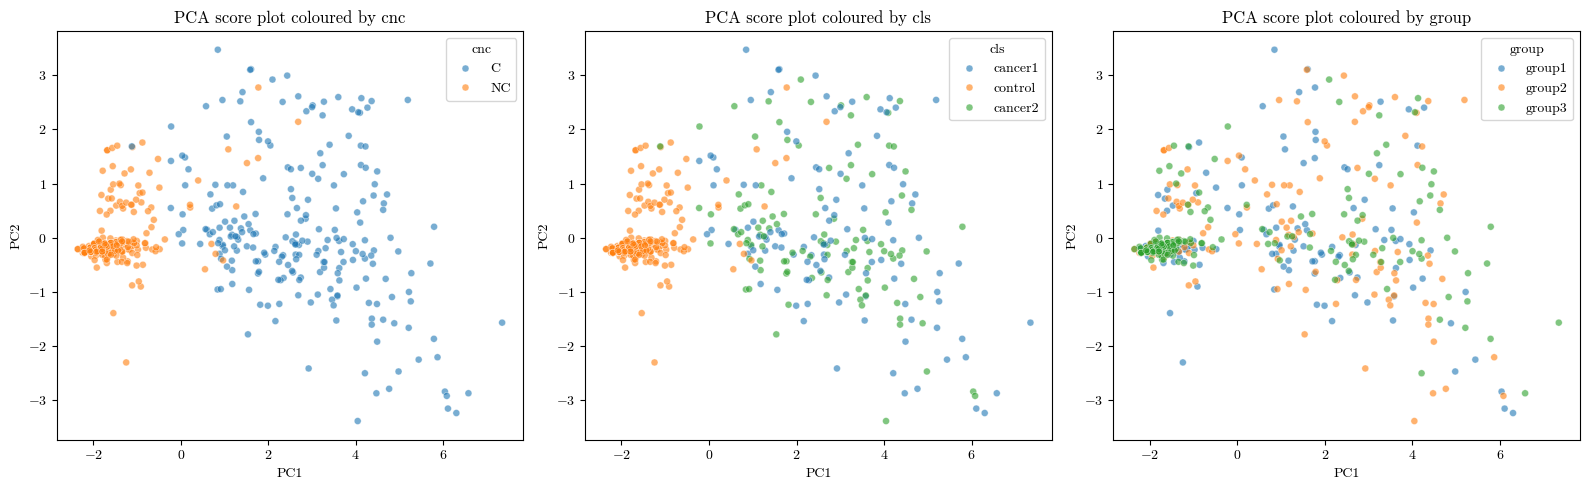

In [45]:
## PCA

features = [f"X_{i}" for i in range(1, 10)]

# One row per patient, keeping the labels alongside the features
patients = Dummy.groupby(["pid", "cnc", "cls", "group"], as_index=False)[features].mean()

# Standardise features, then project to 2 PCA components
X = StandardScaler().fit_transform(patients[features])
pcs = PCA(n_components=2).fit_transform(X)
patients["PC1"], patients["PC2"] = pcs[:, 0], pcs[:, 1]

# Same PCA scores, coloured three different ways
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, label in zip(axes, ["cnc", "cls", "group"]):
    sns.scatterplot(data=patients, x="PC1", y="PC2", hue=label, alpha=0.6, s=25, ax=ax)
    ax.set_title(f"PCA score plot coloured by {label}")
plt.tight_layout()
plt.show()